# Análise Exploratória de Dados - Telco Customer Churn

**Dataset:** [Telco customer churn: IBM dataset](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset)

**Objetivo:** Analisar os fatores que influenciam o cancelamento de clientes (Churn) e preparar o dataset para modelagem preditiva.

## 1. Setup e Imports
Consolidação de todas as bibliotecas necessárias para a análise.

In [1]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import warnings
import math
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

# Uteis
!pip install openpyxl

## 2. Carregamento de Dados
Leitura do dataset e visualização inicial da estrutura.

In [2]:
# Carregar dataset
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

# Visualizar estrutura
print("=== INFORMAÇÕES DO DATASET ===")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas\n")
df.info()
print("\n=== PRIMEIRAS LINHAS ===")
display(df.head())

=== INFORMAÇÕES DO DATASET ===
Dimensões: 7043 linhas x 33 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Mult

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Limpeza e Tratamento de Dados
**Objetivo:** Padronizar nome das colunas e tratar problemas de integridade.

In [3]:
# Padronizar nomes das colunas: lowercase e underscore
df.columns = [c.lower().replace(" ", "_") for c in df.columns]
print("\u2713 Nomes das colunas padronizados")

✓ Nomes das colunas padronizados


In [4]:
# Verificar valores ausentes
print("=== ANÁLISE DE VALORES AUSENTES ===")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

if len(missing_values) > 0:
    print(missing_values)
else:
    print("Não há valores ausentes (NaN).")

# Verificar valores duplicados
print("\n=== ANÁLISE DE VALORES DUPLICADOS ===")
duplicados = df.duplicated().sum()
if duplicados > 0:
    print(f"Há {duplicados} linhas duplicadas.")
else:
    print("Não há valores duplicados.")

# Verificar valores vazios (strings de espaço) em total_charges
print("\n=== ANÁLISE DE VALORES VAZIOS ===")
total_charges_vazios = (df['total_charges'].astype(str).str.strip() == "").sum()
if total_charges_vazios > 0:
    print(f"A coluna 'total_charges' possui {total_charges_vazios} valores vazios (strings de espaço).")
else:
    print("Não há valores vazios em 'total_charges'.")

=== ANÁLISE DE VALORES AUSENTES ===
churn_reason    5174
dtype: int64

=== ANÁLISE DE VALORES DUPLICADOS ===
Não há valores duplicados.

=== ANÁLISE DE VALORES VAZIOS ===
A coluna 'total_charges' possui 11 valores vazios (strings de espaço).


In [5]:
# Investigar correlação entre valores vazios e tenure_months
df['is_total_charges_empty'] = df['total_charges'].astype(str).str.strip() == ""

analise_causa_raiz = df.groupby('is_total_charges_empty')['tenure_months'].agg(
    qtd_clientes='count',
    tenure_minimo='min',
    tenure_maximo='max',
    tenure_medio='mean'
).reset_index()

print("=== CORRELAÇÃO: Total Charges Vazio vs. Tenure ===")
display(analise_causa_raiz)

=== CORRELAÇÃO: Total Charges Vazio vs. Tenure ===


,is_total_charges_empty,qtd_clientes,tenure_minimo,tenure_maximo,tenure_medio
0,False,7032,1,72,32.421786
1,True,11,0,0,0.000000


### Análise de Integridade

Foram identificados **11 registros** na coluna `total_charges` contendo strings vazias (`" "`).

**Causa Raiz:**
Ao cruzar esses dados, observou-se que todos os 11 registros pertencem a clientes com **tenure_months = 0**. Isso indica clientes recém-adquiridos que ainda não possuem histórico de cobrança.

**Ação:**
Substituir valores vazios por **0**, já que representam clientes sem histórico financeiro ainda.

In [6]:
# Converter total_charges para numérico, substituindo espaços vazios por 0
df['total_charges'] = pd.to_numeric(df['total_charges'].replace(" ", 0), errors='coerce').fillna(0)

# Remover flag temporária
df = df.drop(columns=['is_total_charges_empty'])

print("\u2713 Valores vazios corrigidos e flag temporária removida")
print(f"\u2713 Tipo de dados de 'total_charges': {df['total_charges'].dtype}")

✓ Valores vazios corrigidos e flag temporária removida
✓ Tipo de dados de 'total_charges': float64


## 4. Análise Univariada
**Objetivo:** Entender características individuais de cada variável.

### 4.1. Análise de Missing Values
Identificar valores ausentes e entender padrões de distribuição.

In [7]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['missing_count'] > 0].sort_values('missing_count', ascending=False)

if len(missing_values) > 0:
    display(missing_values)
else:
    print("\u2713 Não há valores ausentes no dataset!")

=== ANÁLISE DE MISSING VALUES ===



,column,missing_count,missing_percentage
churn_reason,churn_reason,5174,73.46


### 4.2. Análise de Outliers
Identificar valores extremos que podem ser erros de medição ou casos especiais.

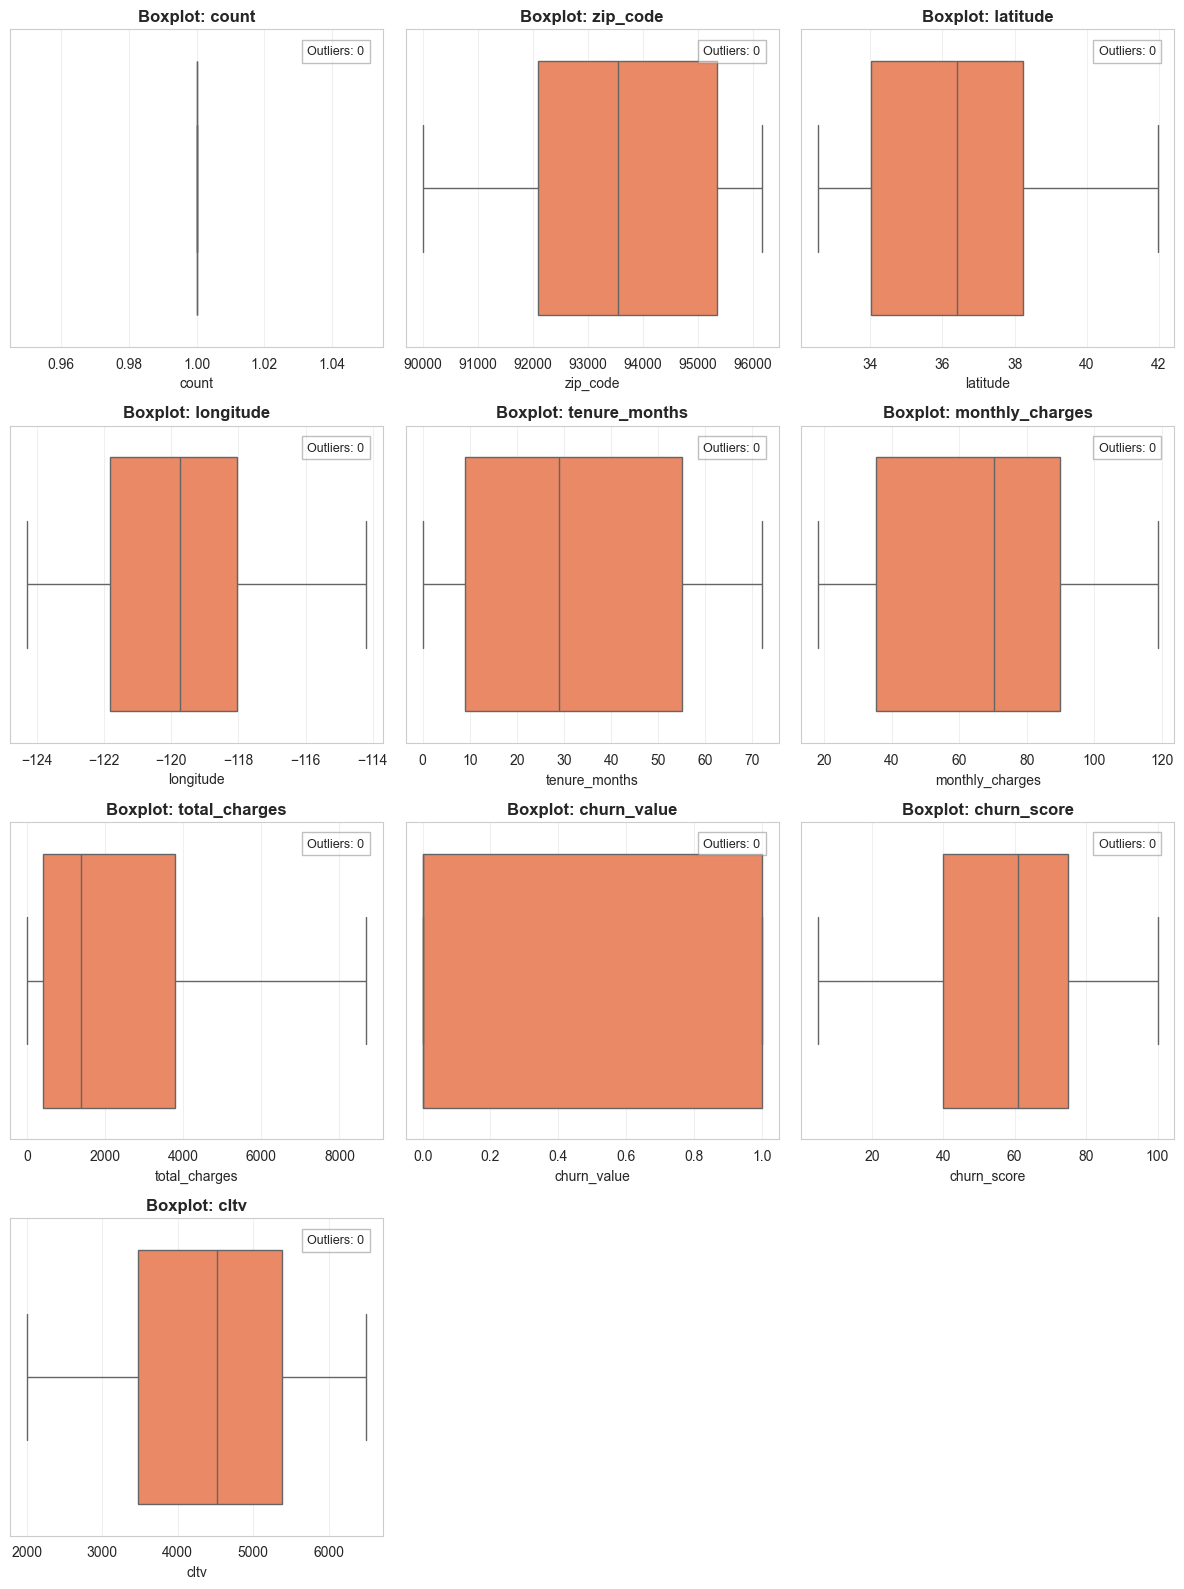

In [8]:
# Colunas numéricas (excluindo id e target se existir)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['customerid', 'target'], errors='ignore')

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Calcular outliers usando Z-Score
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Remover subplots vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Conclusão da Análise de Outliers:**

Duas abordagens complementares foram utilizadas:
1. **Visual (Boxplots):** Observar a dispersão dos dados e valores extremos.
2. **Estatística (Z-Score):** Calcular registros que se afastam mais de 3 desvios padrão da média.

**Resultado:** O contador de outliers (Z-Score > 3) resultou em **0** para todas as variáveis numéricas, indicando distribuições bem delimitadas sem necessidade de tratamento especial.

### 4.3. Análise de Anomalias e Valores Inválidos
Identificar valores que não fazem sentido para o domínio do problema.

In [9]:
anomalies = []

# Variáveis categóricas com valores esperados
categorical_checks = {
    'gender': ['Male', 'Female'],
    'senior_citizen': ['Yes', 'No'],
    'partner': ['Yes', 'No'],
    'dependents': ['Yes', 'No'],
    'phone_service': ['Yes', 'No'],
    'multiple_lines': ['Yes', 'No', 'No phone service'],
    'internet_service': ['DSL', 'Fiber optic', 'No'],
    'online_security': ['Yes', 'No', 'No internet service'],
    'online_backup': ['Yes', 'No', 'No internet service'],
    'device_protection': ['Yes', 'No', 'No internet service'],
    'tech_support': ['Yes', 'No', 'No internet service'],
    'streaming_tv': ['Yes', 'No', 'No internet service'],
    'streaming_movies': ['Yes', 'No', 'No internet service'],
    'contract': ['Month-to-month', 'One year', 'Two year'],
    'paperless_billing': ['Yes', 'No'],
    'payment_method': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
    'churn_label': ['Yes', 'No']
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")

✓ Nenhuma anomalia óbvia detectada nas validações de domínio!


### 4.4. Análise de Distribuições
Entender a distribuição das variáveis numéricas e identificar assimetrias.

In [10]:
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis         Interpretação
          count     0.000     0.000                Normal
       zip_code    -0.251    -1.154                Normal
       latitude     0.304    -1.136                Normal
      longitude    -0.041    -1.136                Normal
  tenure_months     0.240    -1.387                Normal
monthly_charges    -0.221    -1.257                Normal
  total_charges     0.963    -0.229 Assimétrica à direita
    churn_value     1.063    -0.870 Assimétrica à direita
    churn_score    -0.090    -1.006                Normal
           cltv    -0.312    -0.934                Normal


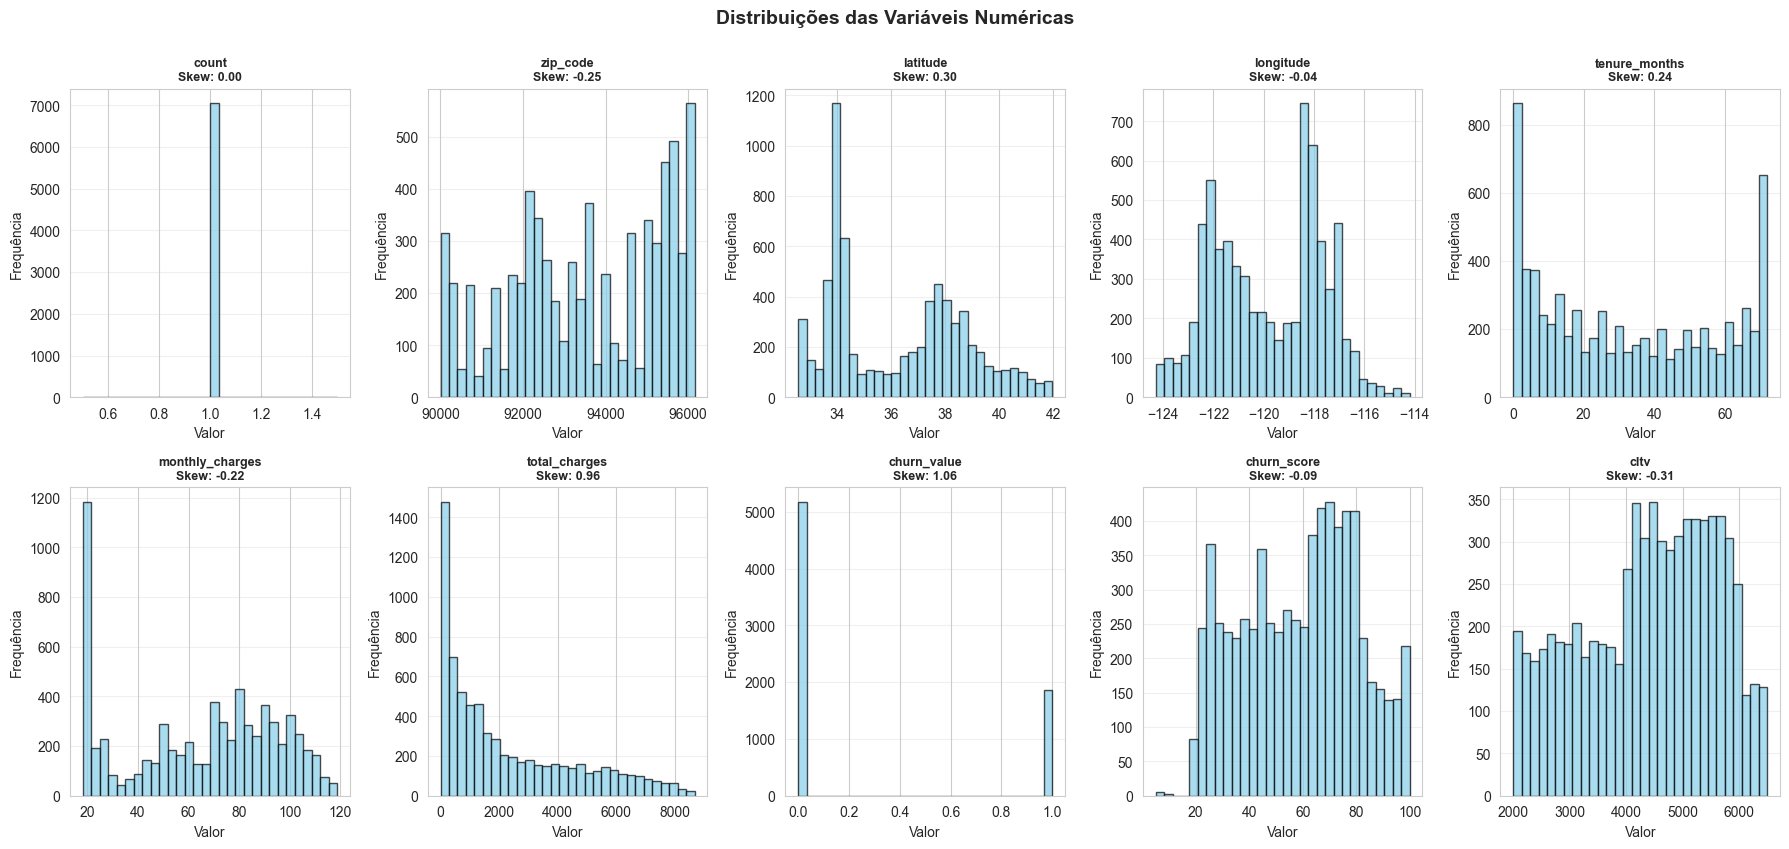

In [11]:
# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5. Análise da Variável Target (Churn)
**Objetivo:** Entender a distribuição da variável alvo e verificar balanceamento de classes.

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

target
0    5174
1    1869
Name: count, dtype: int64

Proporção:
target
0    0.735
1    0.265
Name: proportion, dtype: float64


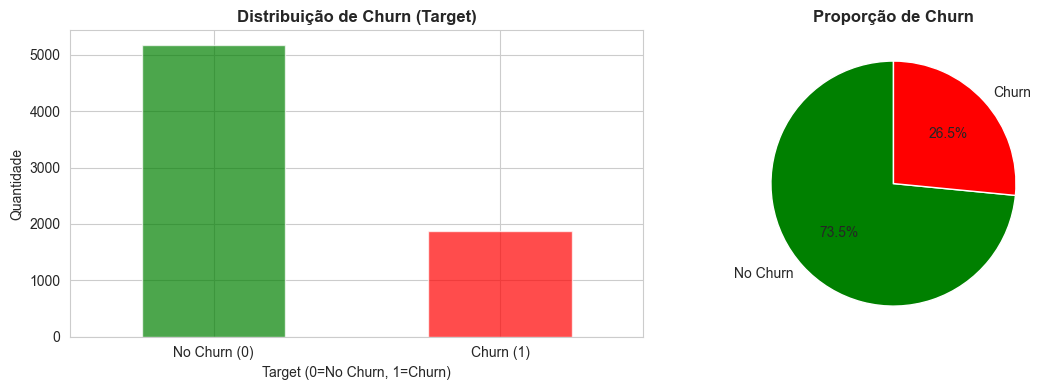

In [12]:
# Renomear churn_value para target
df.rename(columns={'churn_value': 'target'}, inplace=True)

# Converter target para binário (0 = não-churn, 1 = churn)
df['target'] = (df['target'] > 0).astype(int)

# Analisar distribuição
print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
print(df['target'].value_counts())
print("\nProporção:")
print(df['target'].value_counts(normalize=True).round(3))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7)
axes[0].set_title('Distribuição de Churn (Target)', fontweight='bold')
axes[0].set_xlabel('Target (0=No Churn, 1=Churn)')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                  colors=['green', 'red'], labels=['No Churn', 'Churn'], startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporção de Churn', fontweight='bold')

plt.tight_layout()
plt.show()

**⚠️ Observação sobre Desbalanceamento:**

Foi identificado que a classe minoritária **(Churn = 1)** representa apenas **~26,5%** dos dados. Isso caracteriza um **desbalanceamento moderado**.

**Implicações para modelagem:**
* Modelos podem tender a prever a classe majoritária
* Métricas como acurácia podem ser enganosas
* Recomenda-se usar **Precision, Recall, F1-Score e ROC-AUC**
* Técnicas de balanceamento podem ser necessárias (SMOTE, undersampling, class weights)

## 6. Análise Bivariada
**Objetivo:** Identificar relações entre variáveis e seu impacto no churn.

### 6.1. Análise de Correlações
Identificar relações entre variáveis numéricas e detectar multicolinearidade.

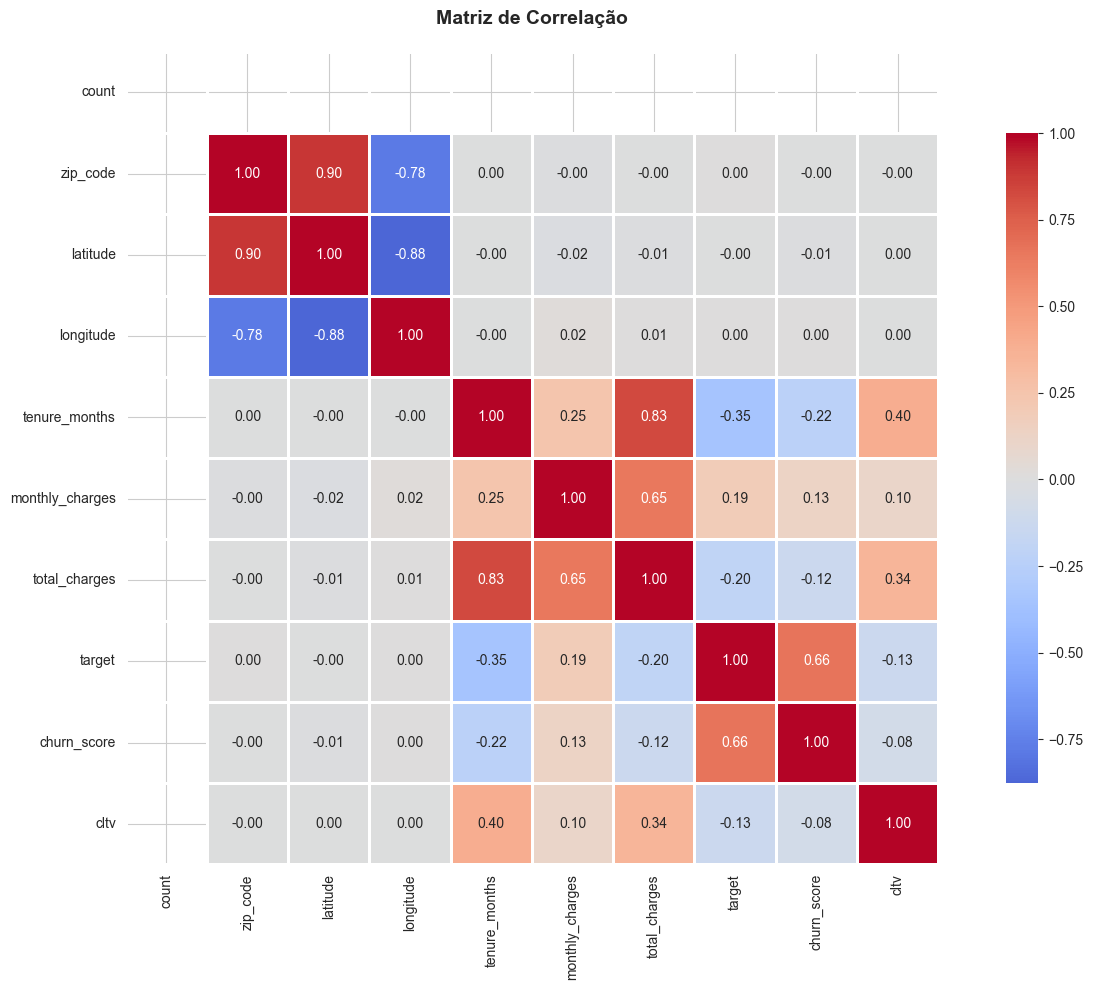

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target             1.000000
churn_score        0.664897
monthly_charges    0.193356
longitude          0.004594
zip_code           0.003346
latitude          -0.003384
cltv              -0.127463
total_charges     -0.198324
tenure_months     -0.352229
count                   NaN
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

    Feature 1     Feature 2  Correlação
     zip_code      latitude       0.896
tenure_months total_charges       0.826
     zip_code     longitude      -0.784
     latitude     longitude      -0.877

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [13]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

**Conclusão da Análise de Correlação:**

Identificada uma correlação forte (~0.826) entre `tenure_months` e `total_charges`.

Essa correlação é esperada (quanto mais tempo o cliente fica, mais ele paga no acumulado), mas para modelos lineares isso pode ser um problema - as variáveis estão "contando a mesma história".

**Recomendações:**
* Considerar exclusão de `total_charges` mantendo `tenure_months` como indicador principal
* Alternativamente, criar feature de "Gasto Médio Mensal" (total_charges / tenure_months)

### 6.2. Impacto do Tipo de Contrato na Retenção
Analisar como o tipo de contrato influencia o tempo de casa e o churn.

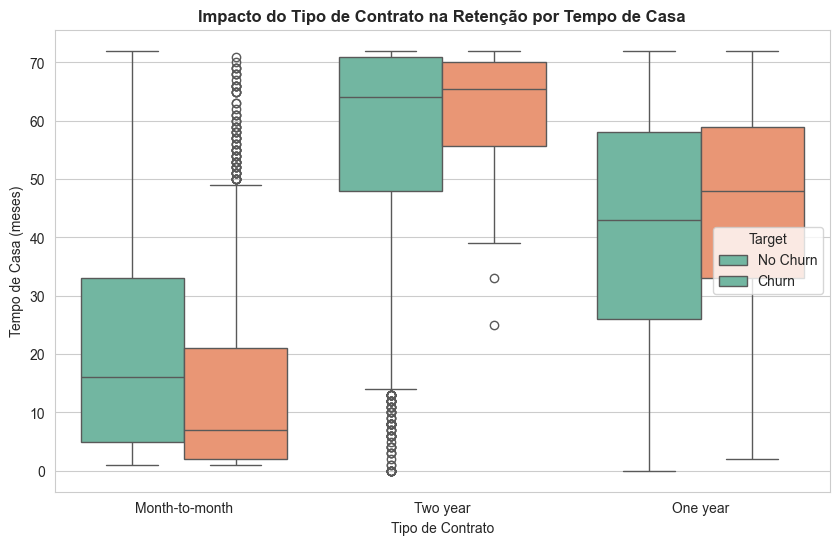

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='contract', y='tenure_months', hue='target', data=df, palette='Set2')
plt.title('Impacto do Tipo de Contrato na Retenção por Tempo de Casa', fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tempo de Casa (meses)')
plt.legend(title='Target', labels=['No Churn', 'Churn'])
plt.show()

**Insights - Fidelidade por Tipo de Contrato:**

Ao cruzar tempo de casa (`tenure_months`) com tipo de contrato, observamos:

1. **Contratos Mensais (Alta Volatilidade):** Churn ocorre majoritariamente nos primeiros 5 meses. Este é o grupo de **maior risco** e exige ações de retenção imediatas.

2. **Contratos de Longo Prazo (Estabilidade):** Contratos de 2 anos são extremamente eficazes em "segurar" o cliente. O churn nesse grupo é raro e acontece apenas após longos períodos (mediana de 50 meses).

3. **Ponto de Atenção:** Clientes que superam os primeiros 20 meses no contrato mensal tendem a se comportar como clientes de longo prazo, indicando que a confiança foi estabelecida.

### 6.3. Impacto dos Serviços no Churn (Contratos Mensais)
Analisar quais serviços influenciam o churn em contratos mensais (grupo de maior risco).

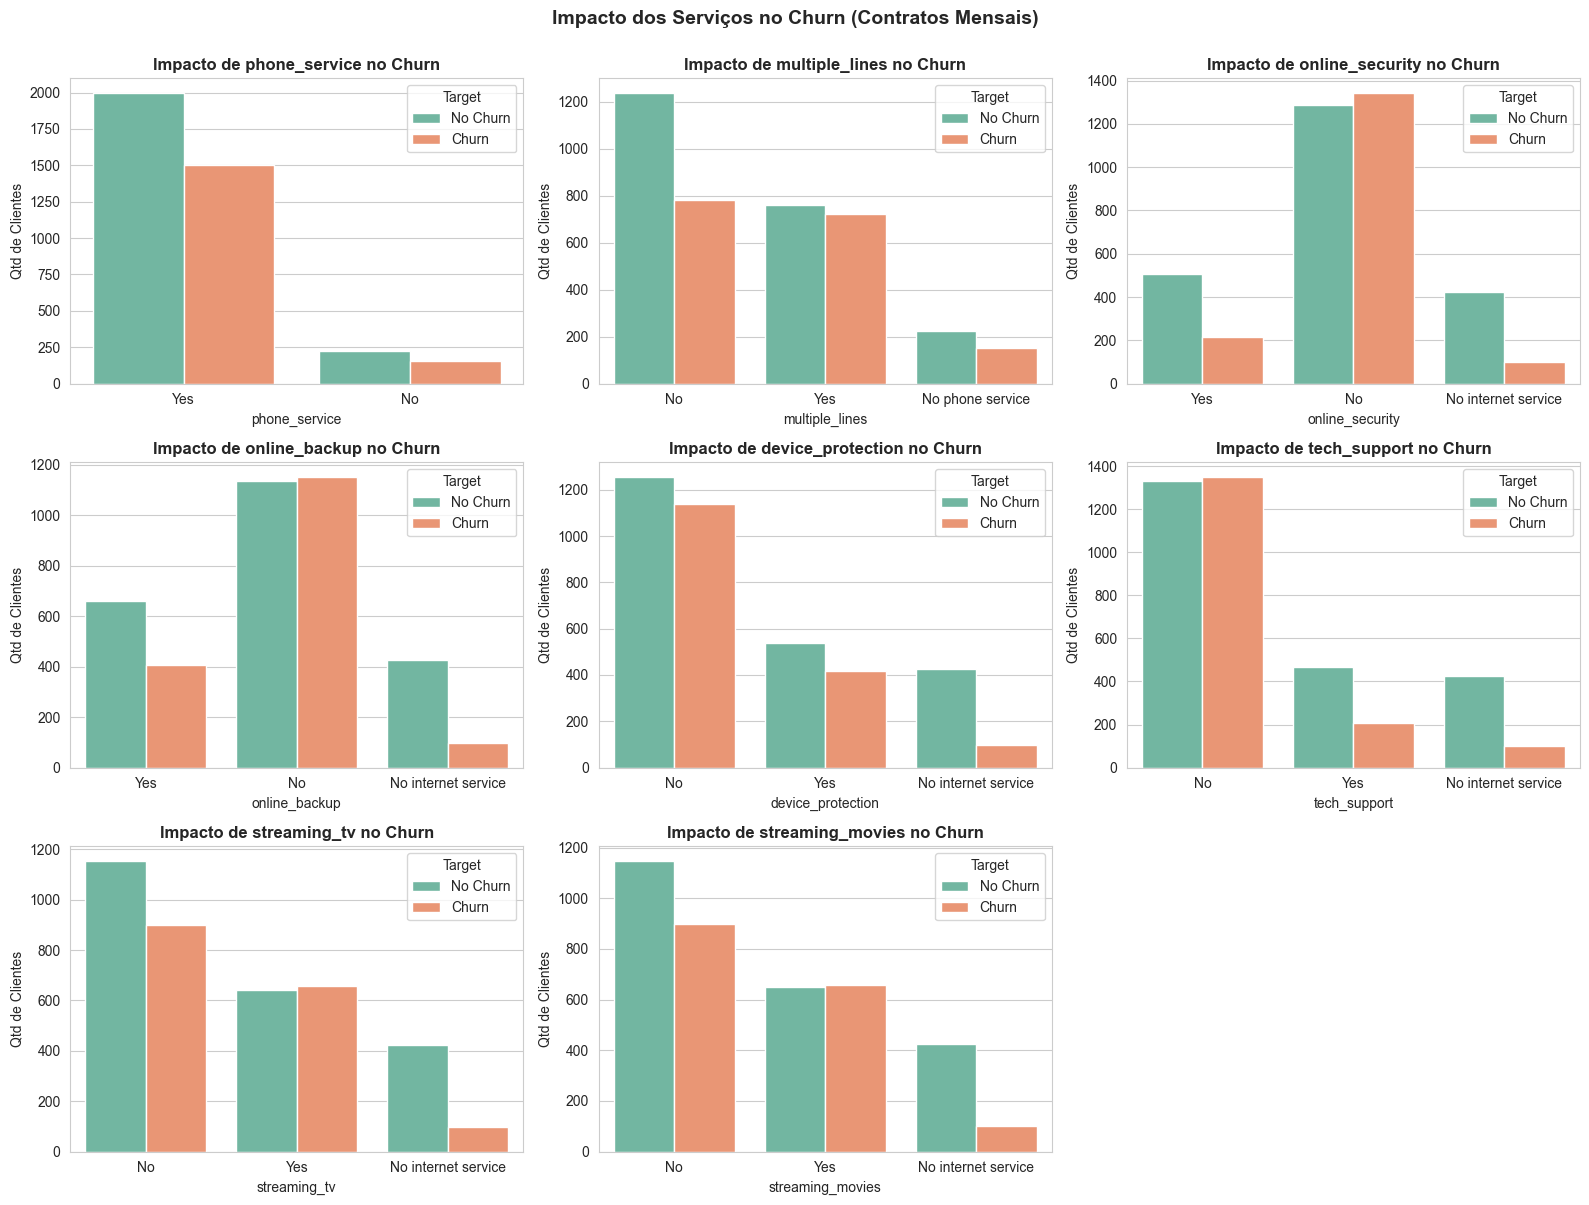

In [15]:
# Lista de serviços para analisar
servicos = [
    'phone_service',
    'multiple_lines',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

# Filtrar apenas contratos mensais (grupo de maior risco)
df_mensal = df[df['contract'] == 'Month-to-month']

plt.figure(figsize=(16, 12))

for i, col in enumerate(servicos):
    plt.subplot(3, 3, i+1)  # Corrigido: 3x3 em vez de 2x2
    sns.countplot(data=df_mensal, x=col, hue='target', palette='Set2')
    plt.title(f'Impacto de {col} no Churn', fontweight='bold')
    plt.ylabel('Qtd de Clientes')
    plt.xlabel(col)
    plt.legend(title='Target', labels=['No Churn', 'Churn'])

plt.suptitle('Impacto dos Serviços no Churn (Contratos Mensais)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. Conclusões e Principais Insights

Resumo dos principais achados da análise exploratória.

### Principais Insights

#### **1. Qualidade dos Dados**
* Dataset limpo e bem estruturado
* Nenhum outlier detectado (Z-Score > 3)
* Nenhuma anomalia de domínio encontrada
* Valores vazios em `total_charges` tratados (11 registros com tenure = 0)

#### **2. Variável Target (Churn)**
* **Desbalanceamento moderado:** ~26,5% de churn vs 73,5% de retenção
* **Implicação:** Requer atenção especial na modelagem (métricas, balanceamento)

#### **3. Multicolinearidade**
* **Alta correlação** entre `tenure_months` e `total_charges` (~0.826)
* **Possibilidade:** Considerar remover `total_charges` ou criar feature de gasto médio mensal

#### **4. Fatores de Risco para Churn**
* **Tipo de Contrato:** Contratos mensais são o grupo de **maior risco**
  * Churn ocorre majoritariamente nos primeiros 5 meses
  * Contratos de 2 anos demonstram alta estabilidade
  
* **Tempo de Casa (Tenure):**
  * Primeiros 20 meses são críticos para contratos mensais
  * Após 20 meses, comportamento se estabiliza

#### **5. Próximos Passos**
1. **Feature Engineering:**
   * Criar `gasto_medio_mensal` = total_charges / tenure_months
   * Criar flag para "clientes novos" (tenure < 6 meses)
   * One-hot encoding de variáveis categóricas

2. **Modelagem:**
   * Considerar técnicas de balanceamento (SMOTE, class weights)
   * Avaliar modelos: Regressão Logística, Random Forest, XGBoost
   * Usar métricas apropriadas: Precision, Recall, F1-Score, ROC-AUC

---
# Experimentação e MVP
### Experimento: Regressão Logística (Baseline)
Treinar um modelo baseline e registre no MLFlow

## 1. Codificação de Variáveis Categóricas

Para que algoritmos de machine learning possam trabalhar com variáveis categóricas, é necessário convertê-las em formato numérico. O método mais comum é o One-hot Encoding, que transforma cada categoria em uma coluna binária (0 ou 1).

### Passos:

- Identificar as features categóricas relevantes.
- Aplicar o `pd.get_dummies()` às features para criar as variáveis dummies.
- Evitar a duplicidade de informação removendo as features de origem (drop_first=True), se necessário.

### Observações:

O One-hot Encoding aumenta o número de colunas, mas permite que modelos interpretem corretamente as categorias.
Após a codificação, salvar o novo dataframe (df_encoded) e utiliza-lo para as etapas de modelagem.

In [16]:
# One-hot encoding das variáveis categóricas relevantes

# Criar a nova feature
# Se tenure_months for 0, o pandas retornará inf ou NaN, então tratamos isso com .replace ou fillna
df['average_monthly_spend'] = df['total_charges'] / df['tenure_months']
df['average_monthly_spend'] = df['average_monthly_spend'].replace([np.inf, -np.inf], 0).fillna(0)

# Dropar as colunas irrelevantes
cols_to_drop = [
    "customerid", 
    "count", 
    "country", 
    "state", 
    "city", 
    "lat_long", 
    "latitude", 
    "longitude", 
    "churn_label", 
    "churn_score", 
    "cltv", 
    "churn_reason", 
    "total_charges", 
    "tenure_months"
]
df_encoded = df.drop(columns=cols_to_drop)

categorical_features = [
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'phone_service',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'contract',
    'paperless_billing',
    'payment_method'
]

## Aplicar one-hot encoding apenas nas features categóricas relevantes
df_encoded = pd.get_dummies(df_encoded, columns=categorical_features, drop_first=True)

print(f"Shape após one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Shape após one-hot encoding: (7043, 31)


,zip_code,monthly_charges,target,average_monthly_spend,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_No phone service,...,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,90003,53.85,1,54.075000,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,90005,70.70,1,75.825000,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,90006,99.65,1,102.562500,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,90010,104.80,1,108.787500,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,90015,103.70,1,102.781633,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


## 2. Separação entre dados de treino e de teste (80/20)

In [17]:
from sklearn.model_selection import train_test_split

# Divisão treino/teste garantindo consistência entre os conjuntos utilizados no pré-processamento e na modelagem.
X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

RANDOM_STATE = 42

# Divisão em conjuntos de treino e teste com os mesmos parâmetros da imputação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## 3. Treinamento do modelo base usando Regressão Logistica

### Definição de funções auxiliares para o treinamento e registro do modelo no MLflow

In [18]:
# Funções helpers para o treinamento e registro de modelos no MLflow

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)


mlflow.set_tracking_uri("file:../data/mlflow_tracking/mlruns")
mlflow.set_experiment("churn_model_classification")


def generate_run_name(
    model_name: str,
    main_configs: dict | None = None
) -> str:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    parts = [model_name.lower()]

    if main_configs:
        for key, value in main_configs.items():
            key = str(key).replace("_", "").replace(" ", "").lower()

            if isinstance(value, bool):
                if value:
                    parts.append(key)
                continue

            value = (
                str(value)
                .replace(" ", "")
                .replace(".", "")
                .replace("/", "")
                .lower()
            )

            parts.append(f"{key}{value}")

    parts.append(timestamp)

    return "_".join(parts)


def build_logistic_regression_importance(model, X_train):
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": model.coef_[0],
    })

    importance_df["absolute_importance"] = (
        importance_df["coefficient"].abs()
    )

    return importance_df.sort_values(
        by="absolute_importance",
        ascending=False
    )


def log_and_show_figure(fig, artifact_name: str, show_plots: bool = True):
    mlflow.log_figure(fig, artifact_name)

    if show_plots:
        plt.show()

    plt.close(fig)


def log_mlflow_run(
    model,
    model_name: str,
    run_name: str,
    hyper_params: dict,
    metrics: dict,
    X_train,
    y_test,
    y_pred_test,
    y_prob_test,
    importance_df: pd.DataFrame | None = None,
    tags: dict | None = None,
    show_plots: bool = True
):
    with mlflow.start_run(run_name=run_name):

        if tags:
            mlflow.set_tags(tags)

        mlflow.log_params(hyper_params)
        mlflow.log_metrics(metrics)

        if importance_df is not None:
            mlflow.log_table(
                importance_df,
                "feature_importance.json"
            )

        fig, ax = plt.subplots(figsize=(8, 6))
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred_test,
            ax=ax
        )
        ax.set_title(f"Confusion Matrix - {model_name}")
        log_and_show_figure(
            fig,
            "confusion_matrix.png",
            show_plots
        )

        fig, ax = plt.subplots(figsize=(8, 6))
        RocCurveDisplay.from_predictions(
            y_test,
            y_prob_test,
            ax=ax
        )
        ax.set_title(f"ROC Curve - {model_name}")
        log_and_show_figure(
            fig,
            "roc_curve.png",
            show_plots
        )

        if importance_df is not None:
            top_features = importance_df.head(15).sort_values(
                by="absolute_importance",
                ascending=True
            )

            fig, ax = plt.subplots(figsize=(10, 6))
            ax.barh(
                top_features["feature"],
                top_features["coefficient"]
            )
            ax.set_title(f"Top 15 Feature Coefficients - {model_name}")
            ax.set_xlabel("Coefficient")

            log_and_show_figure(
                fig,
                "feature_importance_top15.png",
                show_plots
            )

        report = classification_report(
            y_test,
            y_pred_test,
            output_dict=True
        )

        report_df = pd.DataFrame(report).transpose()

        mlflow.log_table(
            report_df,
            "classification_report.json"
        )

        mlflow.sklearn.log_model(
            sk_model=model,
            name="baseline_model"
        )

2026/05/11 18:22:36 INFO mlflow.tracking.fluent: Experiment with name 'churn_model_classification' does not exist. Creating a new experiment.


### Treinamento e avaliação do modelo base

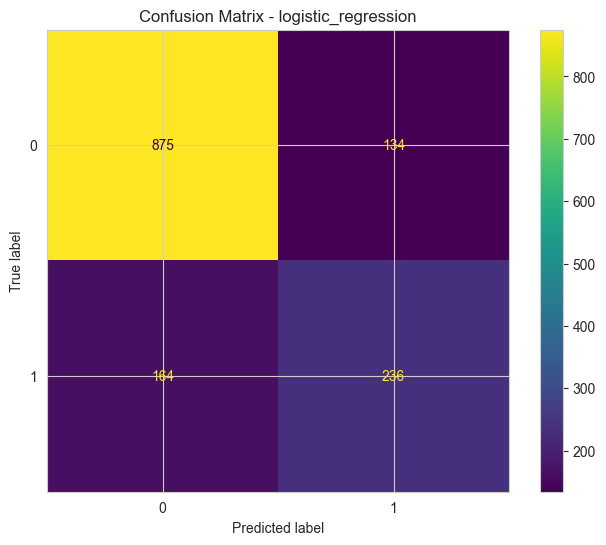

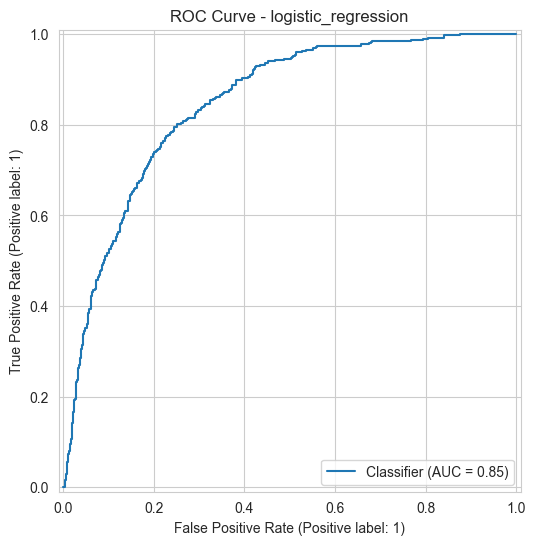

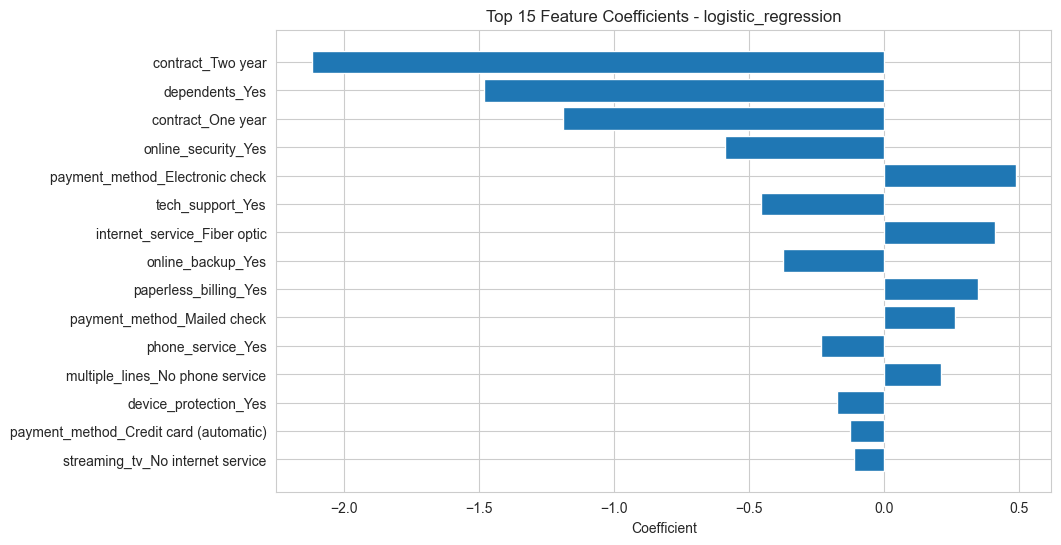

2026/05/11 18:25:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== LOGISTIC_REGRESSION ===
train_accuracy: 0.7985
test_accuracy: 0.7885
test_f1_score: 0.6130
test_precision: 0.6378
test_recall: 0.5900
test_roc_auc: 0.8461
accuracy_gap_train_test: 0.0100

=== TOP FEATURE IMPORTANCE ===


,feature,coefficient,absolute_importance
25,contract_Two year,-2.118788,2.118788
6,dependents_Yes,-1.480724,1.480724
24,contract_One year,-1.189050,1.189050
13,online_security_Yes,-0.587997,0.587997
28,payment_method_Electronic check,0.490657,0.490657
19,tech_support_Yes,-0.454471,0.454471
10,internet_service_Fiber optic,0.410612,0.410612
15,online_backup_Yes,-0.372896,0.372896
26,paperless_billing_Yes,0.350963,0.350963
29,payment_method_Mailed check,0.266038,0.266038


In [ ]:
# Treinamento e registro do modelo de baseline: Logistic Regression
hyper_params = {
    "random_state": RANDOM_STATE,
    "max_iter": 1000,
    "class_weight": "balanced"
}

model_name = "logistic_regression"

run_name = generate_run_name(
    model_name=model_name,
    main_configs={**hyper_params}
)

model = LogisticRegression(**hyper_params)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_prob_test = model.predict_proba(X_test)[:, 1]

metrics = {
    "train_accuracy": accuracy_score(y_train, y_pred_train),
    "test_accuracy": accuracy_score(y_test, y_pred_test),
    "test_f1_score": f1_score(y_test, y_pred_test),
    "test_precision": precision_score(y_test, y_pred_test),
    "test_recall": recall_score(y_test, y_pred_test),
    "test_roc_auc": roc_auc_score(y_test, y_prob_test),
}

metrics["accuracy_gap_train_test"] = (
    metrics["train_accuracy"] - metrics["test_accuracy"]
)

importance_df = build_logistic_regression_importance(
    model,
    X_train
)

mlflow_tags = {
    "model_type": "LogisticRegression",
    "stage": "baseline",
    "dataset": "telco_churn",
    "problem_type": "binary_classification"
}

log_mlflow_run(
    model=model,
    model_name=model_name,
    run_name=run_name,
    hyper_params=hyper_params,
    metrics=metrics,
    X_train=X_train,
    y_test=y_test,
    y_pred_test=y_pred_test,
    y_prob_test=y_prob_test,
    importance_df=importance_df,
    tags=mlflow_tags,
    show_plots=True
)

print(f"=== {model_name.upper()} ===")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\n=== TOP FEATURE IMPORTANCE ===")
display(importance_df.head(15))

## 4. Persistencia do modelo e dataframe pré processado

In [20]:
# Persistir o dataframe pré-processado
df_encoded.to_csv("../data/raw/Telco_customer_churn_preprocessed.csv", index=False)

# Persistir o modelo treinado com MLFlow
mlflow.sklearn.log_model(model, "logistic_regression_model")

# Persistir o modelo usando joblib
import joblib
joblib.dump(model, "../models/baseline_model.joblib")

2026/05/11 18:22:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:22:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


['../models/baseline_model.joblib']